This is a very simple notebook to compute p3d contributions

In [1]:
import h5py
from lace.cosmo import cosmology
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import RegularGridInterpolator
from w1_w2 import compute_w1_w2

In [2]:
wave_log = np.linspace(np.log10(2800), np.log10(6800), 2**12) # Angstrom
wave = 10**wave_log
bias_hcd, bias_lya = 2, -0.18

In [3]:
# MW11 cosmology, for example
hubble, z = 0.71, 2.5
ombh2, omegam = 0.046*(hubble**2), 0.27
omch2 = omegam*(hubble**2)-ombh2
ns, As = 0.96, 2e-9
Fhcd = 0.9779

In [4]:
cosmo = cosmology.Cosmology()
cosmo.CAMBparams.set_cosmology(H0=100*hubble, ombh2=ombh2, omch2=omch2)
cosmo.CAMBparams.InitPower.set_params(As=As, ns=ns)
print('WARNING: Changed to MW11 cosmology (It does not affect the f(NHI, X) function)')

In [5]:
fn_file = '/pscratch/sd/l/lflores/astrid_hcd_outputs/fn_pyigm/fn_pyigm1'

with h5py.File(fn_file, 'r') as f:
    print('Atributes:')
    for m in f.attrs.keys():
        print(f'{m} = {f.attrs[m]}')
    logNHI_max = f.attrs['logNHI_max']
    logNHI_min = f.attrs['logNHI_min']
    print('----------------') 
    print('Data:')
    print(f.keys())

    NHirange = np.linspace(logNHI_min, logNHI_max) 
    logfNHiX = np.interp(NHirange, f['logNhi'][:], f['fn'][:][:, 0])
    fNHiX = 10**(logfNHiX)

Atributes:
Redshift = 2.5
logNHI_max = 21.3
logNHI_min = 17.2
----------------
Data:
<KeysViewHDF5 ['fn', 'logNhi']>


# P3D

## W1 and W2

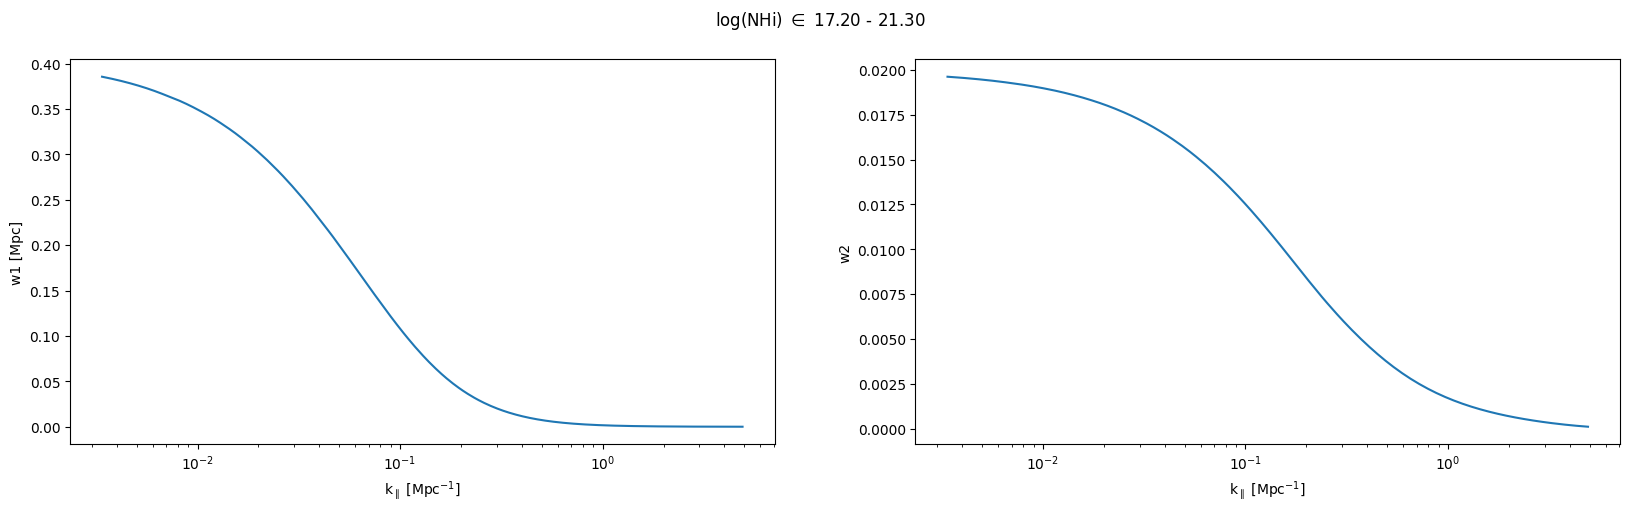

In [6]:
k_w1w2, w1, w2 = compute_w1_w2(wave, NHirange, fNHiX, z, hubble, omegam, resample=True)

plt.figure(figsize=(20, 5))
plt.suptitle(r'log(NHi) $\in$ %.2f - %.2f' %(NHirange.min(), NHirange.max()))

plt.subplot(1, 2, 1)
plt.plot(k_w1w2, w1)
plt.ylabel(r'w1 [Mpc]')
plt.xscale('log')
plt.xlabel(r'k$_\parallel$ [Mpc$^{-1}$]');

plt.subplot(1, 2, 2)
plt.plot(k_w1w2, w2)
plt.ylabel(r'w2')
plt.xscale('log')
plt.xlabel(r'k$_\parallel$ [Mpc$^{-1}$]');

In [7]:
bias_hcd_flux = -2*w2[1]/Fhcd  # Warning, this depends a lot on the cosmology
bias_hcd_flux

np.float64(-0.04012635028537484)

We will work in a grid of (k, mu), so for each value we will have a different k_los array. Let's create then the k_los grid and interpolate the w1 and w2 functions to it

In [8]:
mu = np.linspace(0, 1, 11)
k = np.logspace(-2.5, 0.5, len(k_w1w2))
k_los = k*mu[:, None]
k_perp = np.sqrt(k**2 - k_los**2)

w1_grid = np.interp(k_los, k_w1w2, w1)
w2_grid = np.interp(k_los, k_w1w2, w2)

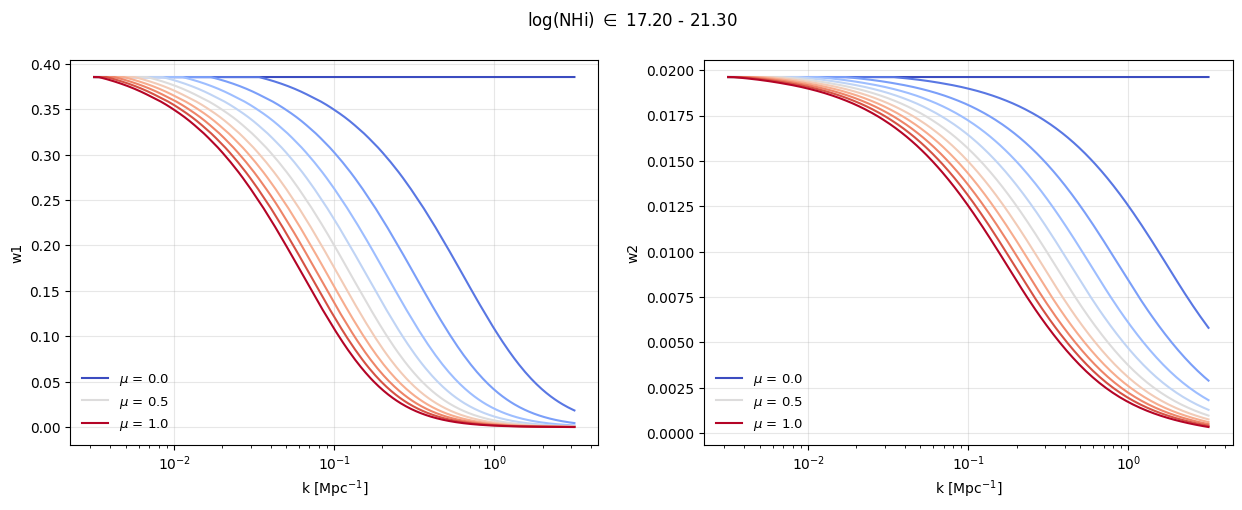

In [9]:
plt.figure(figsize=(15, 5))
plt.suptitle(r'log(NHi) $\in$ %.2f - %.2f' %(NHirange.min(), NHirange.max()))

plt.subplot(1, 2, 1)
colors = plt.cm.coolwarm(np.linspace(0,1,len(mu)))     
plt.gca().set_prop_cycle('color', colors)

for i in np.arange(len(mu)):
    if i in [0, 5, 10]:
        plt.plot(k, w1_grid[i, :], label = '$\mu$ = %.1f' %mu[i])
    else:
        plt.plot(k, w1_grid[i, :])
plt.xscale('log')
plt.grid(alpha=0.3)
plt.legend(fontsize=9.5, frameon=False)
plt.xlabel(r'k [Mpc$^{-1}$]')
plt.ylabel(r'w1');

plt.subplot(1, 2, 2)
colors = plt.cm.coolwarm(np.linspace(0,1,len(mu)))     
plt.gca().set_prop_cycle('color', colors)

for i in np.arange(len(mu)):
    if i in [0, 5, 10]:
        plt.plot(k, w2_grid[i, :], label = '$\mu$ = %.1f' %mu[i])
    else:
        plt.plot(k, w2_grid[i, :])
plt.xscale('log')
plt.grid(alpha=0.3)
plt.legend(fontsize=9.5, frameon=False)
plt.xlabel(r'k [Mpc$^{-1}$]')
plt.ylabel(r'w2');

## Plin

In [10]:
plin = cosmo.get_linP_Mpc(z, k)

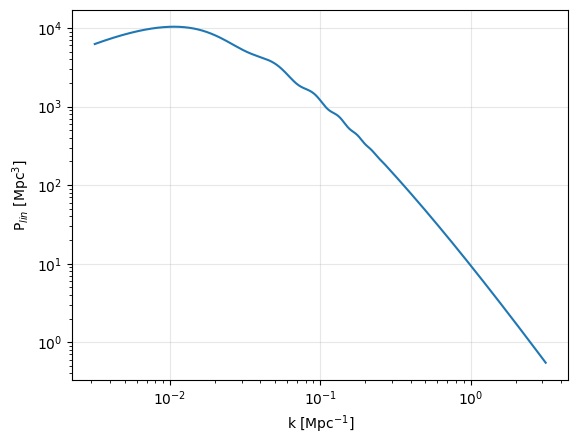

In [11]:
plt.plot(k, plin)
plt.xscale('log')
plt.yscale('log')
plt.grid(alpha=0.3)
plt.xlabel(r'k [Mpc$^{-1}$]')
plt.ylabel(r'P$_{lin}$ [Mpc$^{3}$]');

## HCD field

In [12]:
p3d_hcd = (w2_grid**2)*((bias_hcd+mu[:, None]**2)**2)*plin

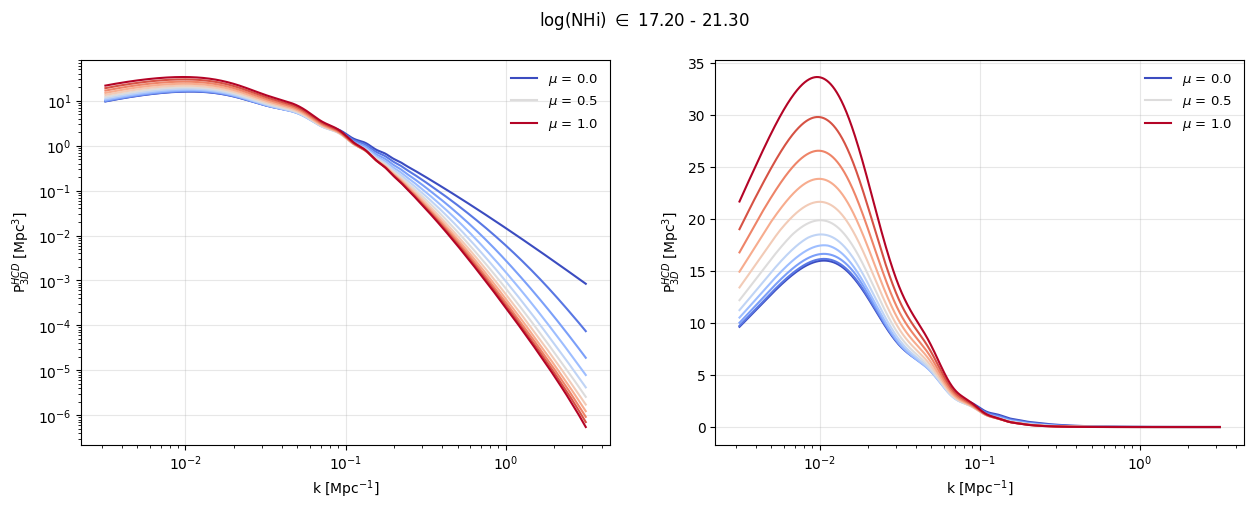

In [13]:
plt.figure(figsize=(15, 5))
plt.suptitle(r'log(NHi) $\in$ %.2f - %.2f' %(NHirange.min(), NHirange.max()));

plt.subplot(1, 2, 1)
colors = plt.cm.coolwarm(np.linspace(0,1,len(mu)))     
plt.gca().set_prop_cycle('color', colors)

for i in np.arange(len(mu)):
    if i in [0, 5, 10]:
        plt.plot(k, p3d_hcd[i, :], label = '$\mu$ = %.1f' %mu[i])
    else:
        plt.plot(k, p3d_hcd[i, :])
plt.xscale('log')
plt.yscale('log')
plt.grid(alpha=0.3)
plt.legend(fontsize=9.5, frameon=False)
plt.xlabel(r'k [Mpc$^{-1}$]')
plt.ylabel(r'P$_{3D}^{HCD}$ [Mpc$^{3}$]');

plt.subplot(1, 2, 2)
colors = plt.cm.coolwarm(np.linspace(0,1,len(mu)))     
plt.gca().set_prop_cycle('color', colors)

for i in np.arange(len(mu)):
    if i in [0, 5, 10]:
        plt.plot(k, p3d_hcd[i, :], label = '$\mu$ = %.1f' %mu[i])
    else:
        plt.plot(k, p3d_hcd[i, :])
plt.xscale('log')
plt.grid(alpha=0.3)
plt.legend(fontsize=9.5, frameon=False)
plt.xlabel(r'k [Mpc$^{-1}$]')
plt.ylabel(r'P$_{3D}^{HCD}$ [Mpc$^{3}$]');

## Lya field

In [14]:
dkms_dMpc = cosmo.get_dkms_dMpc(z)
k_d = 0.08*dkms_dMpc  # Mpc^-1
exp = np.exp(-(k_los**2/k_d**2))
p3d_lya = (bias_lya**2)*((1+mu[:, None]**2)**2)*exp*plin

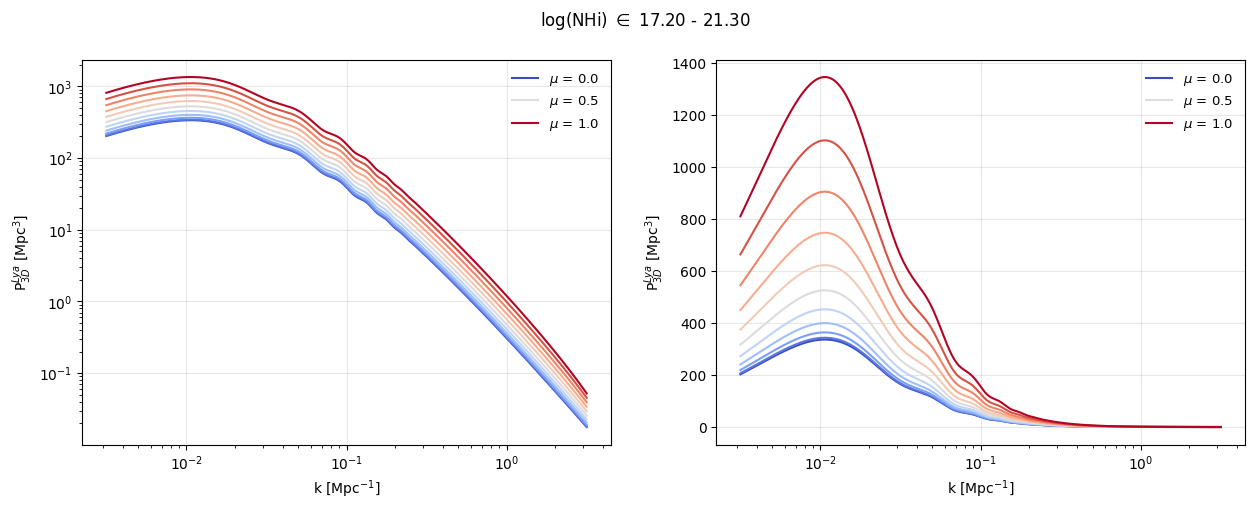

In [15]:
plt.figure(figsize=(15, 5))
plt.suptitle(r'log(NHi) $\in$ %.2f - %.2f' %(NHirange.min(), NHirange.max()));

plt.subplot(1, 2, 1)
colors = plt.cm.coolwarm(np.linspace(0,1,len(mu)))     
plt.gca().set_prop_cycle('color', colors)

for i in np.arange(len(mu)):
    if i in [0, 5, 10]:
        plt.plot(k, p3d_lya[i, :], label = '$\mu$ = %.1f' %mu[i])
    else:
        plt.plot(k, p3d_lya[i, :])
plt.xscale('log')
plt.yscale('log')
plt.grid(alpha=0.3)
plt.legend(fontsize=9.5, frameon=False)
plt.xlabel(r'k [Mpc$^{-1}$]')
plt.ylabel(r'P$_{3D}^{Lya}$ [Mpc$^{3}$]');

plt.subplot(1, 2, 2)
colors = plt.cm.coolwarm(np.linspace(0,1,len(mu)))     
plt.gca().set_prop_cycle('color', colors)

for i in np.arange(len(mu)):
    if i in [0, 5, 10]:
        plt.plot(k, p3d_lya[i, :], label = '$\mu$ = %.1f' %mu[i])
    else:
        plt.plot(k, p3d_lya[i, :])
plt.xscale('log')
plt.grid(alpha=0.3)
plt.legend(fontsize=9.5, frameon=False)
plt.xlabel(r'k [Mpc$^{-1}$]')
plt.ylabel(r'P$_{3D}^{Lya}$ [Mpc$^{3}$]');

## HCD x Lya field

In [16]:
p3d = []
dkms_dMpc = cosmo.get_dkms_dMpc(z)
k_d = 0.08*dkms_dMpc  # Mpc^-1
exp = np.exp(-(k_los**2/k_d**2))
p3d_lyahcd = w2_grid*(np.abs(bias_hcd) + mu[:, None]**2)*np.abs(bias_lya)*(1 + mu[:, None]**2)*plin*np.sqrt(exp)

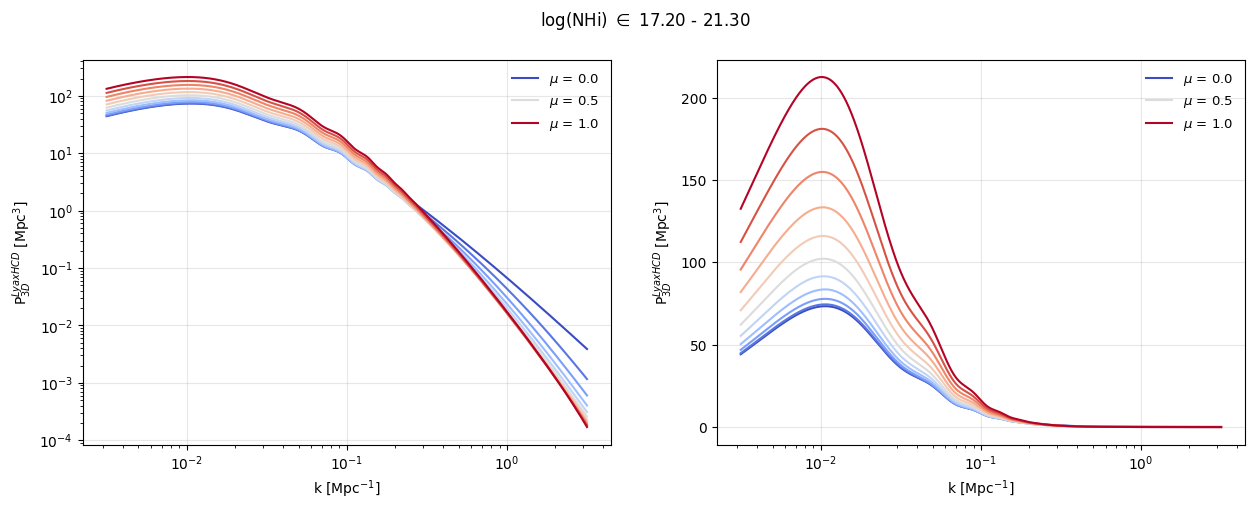

In [17]:
plt.figure(figsize=(15, 5))
plt.suptitle(r'log(NHi) $\in$ %.2f - %.2f' %(NHirange.min(), NHirange.max()));

plt.subplot(1, 2, 1)
colors = plt.cm.coolwarm(np.linspace(0,1,len(mu)))     
plt.gca().set_prop_cycle('color', colors)

for i in np.arange(len(mu)):
    if i in [0, 5, 10]:
        plt.plot(k, p3d_lyahcd[i, :], label = '$\mu$ = %.1f' %mu[i])
    else:
        plt.plot(k, p3d_lyahcd[i, :])
plt.xscale('log')
plt.yscale('log')
plt.grid(alpha=0.3)
plt.legend(fontsize=9.5, frameon=False)
plt.xlabel(r'k [Mpc$^{-1}$]')
plt.ylabel(r'P$_{3D}^{LyaxHCD}$ [Mpc$^{3}$]');

plt.subplot(1, 2, 2)
colors = plt.cm.coolwarm(np.linspace(0,1,len(mu)))     
plt.gca().set_prop_cycle('color', colors)

for i in np.arange(len(mu)):
    if i in [0, 5, 10]:
        plt.plot(k, p3d_lyahcd[i, :], label = '$\mu$ = %.1f' %mu[i])
    else:
        plt.plot(k, p3d_lyahcd[i, :])
plt.xscale('log')
plt.grid(alpha=0.3)
plt.legend(fontsize=9.5, frameon=False)
plt.xlabel(r'k [Mpc$^{-1}$]')
plt.ylabel(r'P$_{3D}^{LyaxHCD}$ [Mpc$^{3}$]');

## Total

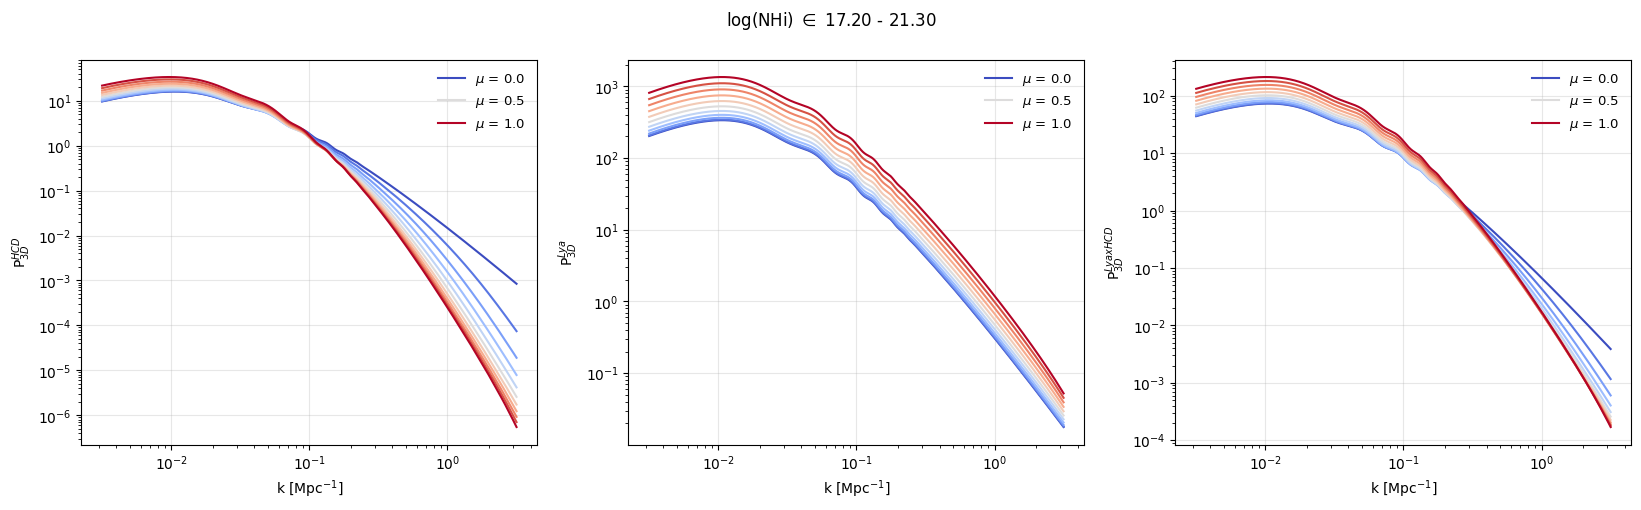

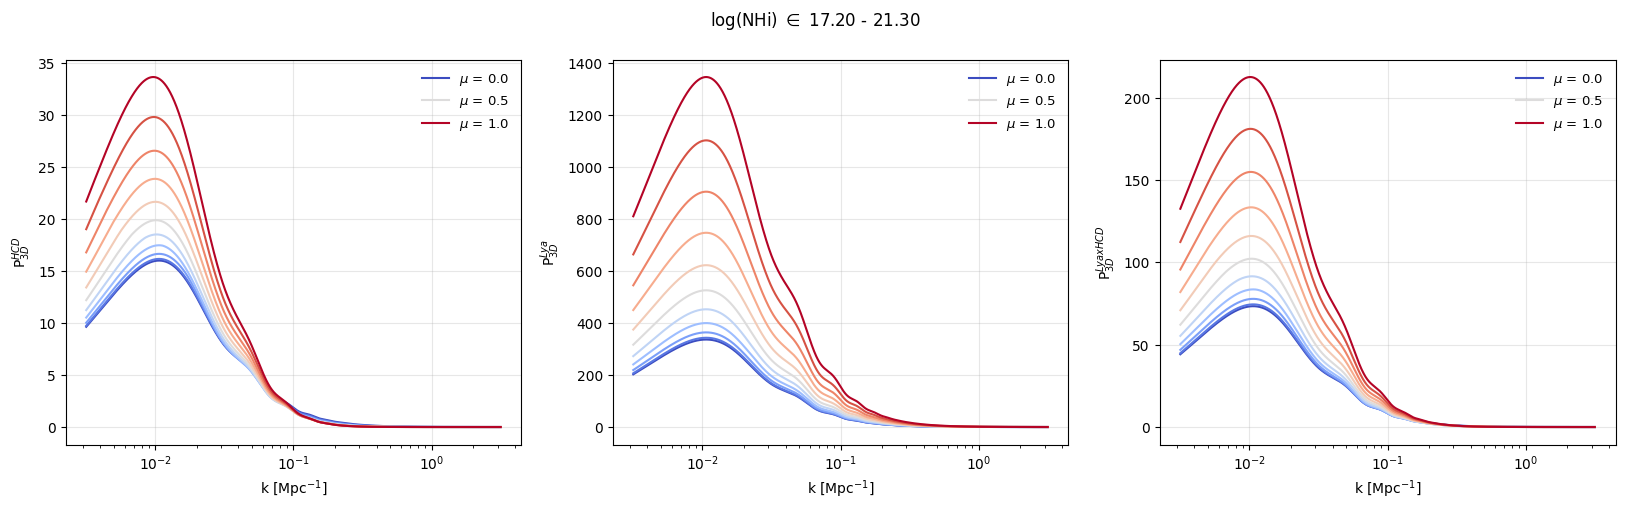

In [18]:
plt.figure(figsize=(20, 5))
plt.suptitle(r'log(NHi) $\in$ %.2f - %.2f' %(NHirange.min(), NHirange.max()))

plt.subplot(1, 3, 1)
colors = plt.cm.coolwarm(np.linspace(0,1,len(mu)))     
plt.gca().set_prop_cycle('color', colors)

for i in np.arange(len(mu)):
    if i in [0, 5, 10]:
        plt.plot(k, p3d_hcd[i, :], label = '$\mu$ = %.1f' %mu[i])
    else:
        plt.plot(k, p3d_hcd[i, :])
plt.xscale('log')
plt.yscale('log')
plt.grid(alpha=0.3)
plt.legend(fontsize=9.5, frameon=False)
plt.xlabel(r'k [Mpc$^{-1}$]')
plt.ylabel(r'P$_{3D}^{HCD}$');

plt.subplot(1, 3, 2)
colors = plt.cm.coolwarm(np.linspace(0,1,len(mu)))     
plt.gca().set_prop_cycle('color', colors)

for i in np.arange(len(mu)):
    if i in [0, 5, 10]:
        plt.plot(k, p3d_lya[i, :], label = '$\mu$ = %.1f' %mu[i])
    else:
        plt.plot(k, p3d_lya[i, :])
plt.xscale('log')
plt.yscale('log')
plt.grid(alpha=0.3)
plt.legend(fontsize=9.5, frameon=False)
plt.xlabel(r'k [Mpc$^{-1}$]')
plt.ylabel(r'P$_{3D}^{Lya}$');

plt.subplot(1, 3, 3)
colors = plt.cm.coolwarm(np.linspace(0,1,len(mu)))     
plt.gca().set_prop_cycle('color', colors)

for i in np.arange(len(mu)):
    if i in [0, 5, 10]:
        plt.plot(k, p3d_lyahcd[i, :], label = '$\mu$ = %.1f' %mu[i])
    else:
        plt.plot(k, p3d_lyahcd[i, :])
plt.xscale('log')
plt.yscale('log')
plt.grid(alpha=0.3)
plt.legend(fontsize=9.5, frameon=False)
plt.xlabel(r'k [Mpc$^{-1}$]')
plt.ylabel(r'P$_{3D}^{LyaxHCD}$');

plt.figure(figsize=(20, 5))
plt.suptitle(r'log(NHi) $\in$ %.2f - %.2f' %(NHirange.min(), NHirange.max()))

plt.subplot(1, 3, 1)
colors = plt.cm.coolwarm(np.linspace(0,1,len(mu)))     
plt.gca().set_prop_cycle('color', colors)

for i in np.arange(len(mu)):
    if i in [0, 5, 10]:
        plt.plot(k, p3d_hcd[i, :], label = '$\mu$ = %.1f' %mu[i])
    else:
        plt.plot(k, p3d_hcd[i, :])
plt.xscale('log')
plt.grid(alpha=0.3)
plt.legend(fontsize=9.5, frameon=False)
plt.xlabel(r'k [Mpc$^{-1}$]')
plt.ylabel(r'P$_{3D}^{HCD}$');

plt.subplot(1, 3, 2)
colors = plt.cm.coolwarm(np.linspace(0,1,len(mu)))     
plt.gca().set_prop_cycle('color', colors)

for i in np.arange(len(mu)):
    if i in [0, 5, 10]:
        plt.plot(k, p3d_lya[i, :], label = '$\mu$ = %.1f' %mu[i])
    else:
        plt.plot(k, p3d_lya[i, :])
plt.xscale('log')
plt.grid(alpha=0.3)
plt.legend(fontsize=9.5, frameon=False)
plt.xlabel(r'k [Mpc$^{-1}$]')
plt.ylabel(r'P$_{3D}^{Lya}$');

plt.subplot(1, 3, 3)
colors = plt.cm.coolwarm(np.linspace(0,1,len(mu)))     
plt.gca().set_prop_cycle('color', colors)

for i in np.arange(len(mu)):
    if i in [0, 5, 10]:
        plt.plot(k, p3d_lyahcd[i, :], label = '$\mu$ = %.1f' %mu[i])
    else:
        plt.plot(k, p3d_lyahcd[i, :])
plt.xscale('log')
plt.grid(alpha=0.3)
plt.legend(fontsize=9.5, frameon=False)
plt.xlabel(r'k [Mpc$^{-1}$]')
plt.ylabel(r'P$_{3D}^{LyaxHCD}$');

Because of the interpolation of w1 and w2 we have some nan values in w1_grid and w2_grid. To avoid that np.nan + number = np.nan we do:

In [19]:
p3d_hcd_nonan, p3d_lya_nonan, p3d_lyahcd_nonan = p3d_hcd.copy(), p3d_lya.copy(), p3d_lyahcd.copy()
np.nan_to_num(p3d_hcd_nonan, 0), np.nan_to_num(p3d_lya_nonan, 0), np.nan_to_num(p3d_lyahcd_nonan, 0)
p3d_total = p3d_hcd_nonan + p3d_lya_nonan + 2*p3d_lyahcd_nonan

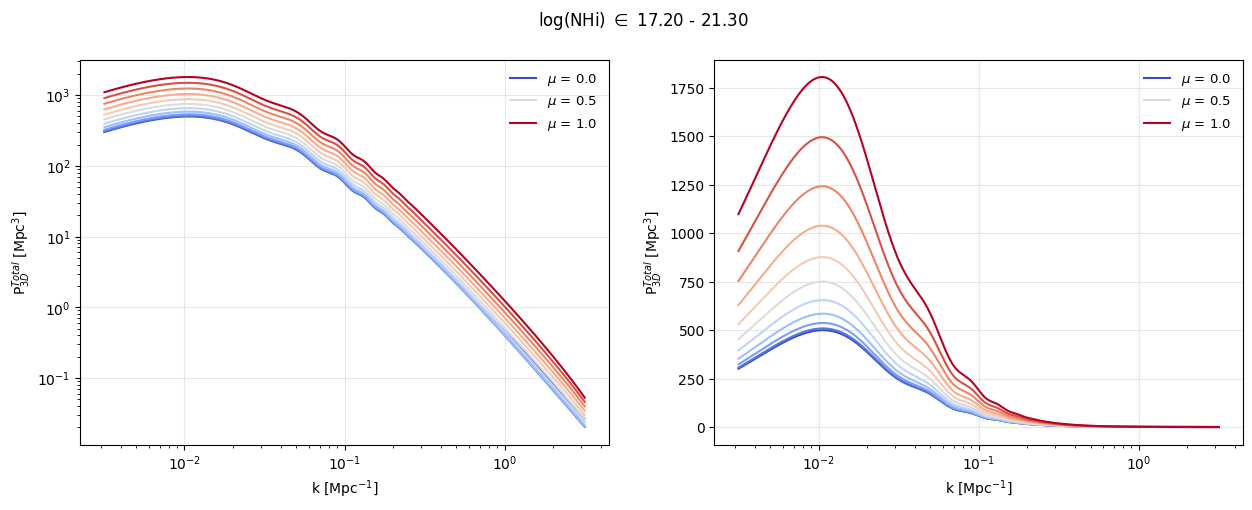

In [20]:
plt.figure(figsize=(15, 5))
plt.suptitle(r'log(NHi) $\in$ %.2f - %.2f' %(NHirange.min(), NHirange.max()));

plt.subplot(1, 2, 1)
colors = plt.cm.coolwarm(np.linspace(0,1,len(mu)))     
plt.gca().set_prop_cycle('color', colors)

for i in np.arange(len(mu)):
    if i in [0, 5, 10]:
        plt.plot(k, p3d_total[i, :], label = '$\mu$ = %.1f' %mu[i])
    else:
        plt.plot(k, p3d_total[i, :])
plt.xscale('log')
plt.yscale('log')
plt.grid(alpha=0.3)
plt.legend(fontsize=9.5, frameon=False)
plt.xlabel(r'k [Mpc$^{-1}$]')
plt.ylabel(r'P$_{3D}^{Total}$ [Mpc$^{3}$]');

plt.subplot(1, 2, 2)
colors = plt.cm.coolwarm(np.linspace(0,1,len(mu)))     
plt.gca().set_prop_cycle('color', colors)

for i in np.arange(len(mu)):
    if i in [0, 5, 10]:
        plt.plot(k, p3d_total[i, :], label = '$\mu$ = %.1f' %mu[i])
    else:
        plt.plot(k, p3d_total[i, :])
plt.xscale('log')
plt.grid(alpha=0.3)
plt.legend(fontsize=9.5, frameon=False)
plt.xlabel(r'k [Mpc$^{-1}$]')
plt.ylabel(r'P$_{3D}^{Total}$ [Mpc$^{3}$]');

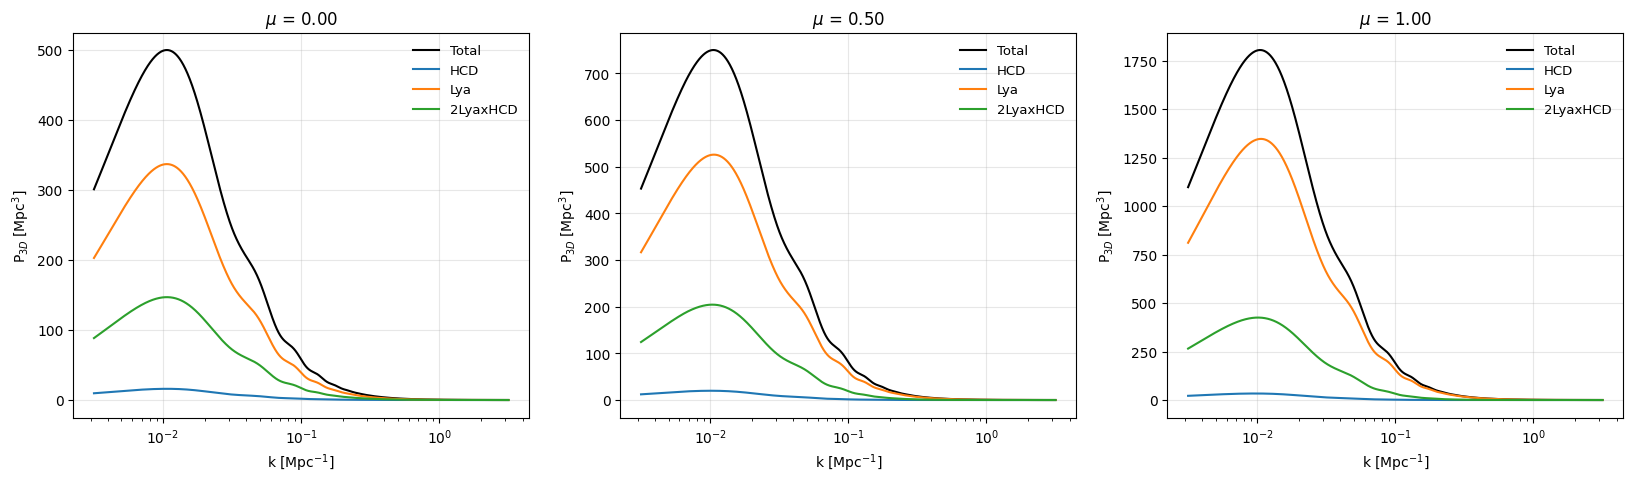

In [21]:
plt.figure(figsize=(20, 5))

plt.subplot(1, 3, 1)
i = 0
plt.plot(k, p3d_total[i], color='k', label='Total')
plt.plot(k, p3d_hcd[i], label='HCD')
plt.plot(k, p3d_lya[i], label='Lya')
plt.plot(k, 2*p3d_lyahcd[i], label='2LyaxHCD')

plt.xscale('log')
plt.grid(alpha=0.3)
plt.legend(fontsize=9.5, frameon=False)
plt.xlabel(r'k [Mpc$^{-1}$]')
plt.ylabel(r'P$_{3D}$ [Mpc$^{3}$]')
plt.title(r'$\mu$ = %.2f' %mu[i])

plt.subplot(1, 3, 2)
i = 5
plt.plot(k, p3d_total[i], color='k', label='Total')
plt.plot(k, p3d_hcd[i], label='HCD')
plt.plot(k, p3d_lya[i], label='Lya')
plt.plot(k, 2*p3d_lyahcd[i], label='2LyaxHCD')
plt.xscale('log')
plt.grid(alpha=0.3)
plt.legend(fontsize=9.5, frameon=False)
plt.xlabel(r'k [Mpc$^{-1}$]')
plt.ylabel(r'P$_{3D}$ [Mpc$^{3}$]')
plt.title(r'$\mu$ = %.2f' %mu[i])

plt.subplot(1, 3, 3)
i = 10
plt.plot(k, p3d_total[i], color='k', label='Total')
plt.plot(k, p3d_hcd[i], label='HCD')
plt.plot(k, p3d_lya[i], label='Lya')
plt.plot(k, 2*p3d_lyahcd[i], label='2LyaxHCD')
plt.xscale('log')
plt.grid(alpha=0.3)
plt.legend(fontsize=9.5, frameon=False)
plt.xlabel(r'k [Mpc$^{-1}$]')
plt.ylabel(r'P$_{3D}$ [Mpc$^{3}$]')
plt.title(r'$\mu$ = %.2f' %mu[i]);

## Comparison with MW11

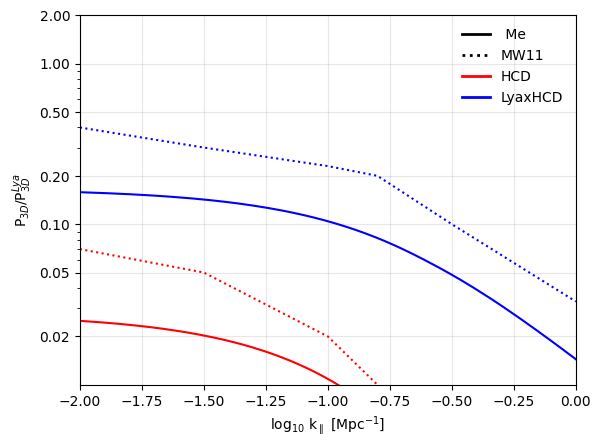

In [22]:
from matplotlib.lines import Line2D

k_mw11 = [-2, -1.5, -1, -0.8, -0.5, 0]
ratio_hcd_mw11 = [0.07, 0.05, 0.02, 0.01, np.nan, np.nan]
ratio_lyahcd_mw11 = [0.4, 0.3, 0.23, 0.2, 0.1, 0.033]

i = 10  # So that k = k_los
plt.plot(np.log10(k), p3d_hcd[i]/p3d_lya[i], color='red', label='HCD')
plt.plot(k_mw11, ratio_hcd_mw11, color='red', linestyle=':', label='MW11')
plt.plot(np.log10(k), p3d_lyahcd[i]/p3d_lya[i], color='blue', label='Me')
plt.plot(k_mw11, ratio_lyahcd_mw11, color='blue', linestyle=':', label='LyaxHCD')
plt.yscale('log')
yticks = np.array([0.02, 0.05, 0.10, 0.20, 0.50, 1.00, 2.00])
plt.yticks(yticks, [f"{y:.2f}" for y in yticks])
plt.grid(alpha=0.3)
handles = [Line2D([0], [0], color='black', lw=2, linestyle='-', label=' Me'),
    Line2D([0], [0], color='black', lw=2, linestyle=':', label='MW11'),
    Line2D([0], [0], color='red', lw=2, label='HCD'),
    Line2D([0], [0], color='blue', lw=2, label=r'LyaxHCD')]
plt.legend(handles=handles, frameon=False)
plt.xlabel(r'log$_{10}$ k$_\parallel$ [Mpc$^{-1}$]')
plt.ylabel(r'P$_{3D}$/P$_{3D}^{Lya}$')
plt.xlim(-2, 0)
plt.ylim(0.01, 2);

In [79]:
def P3D_hcd_model(z, k, mu, p3d_params, new_cosmo_params):
    """
    This is an interpolator of the previously obtained P3D model
    """
    coordinates = 'k_mu'
    cosmo = cosmology.Cosmology(cosmo_params_dict=new_cosmo_params)
    plin = cosmo.get_linP_Mpc(z, k)

    kpar = k * mu
    w2_eval = np.interp(kpar, k_w1w2, w2)
    
    p3d_hcd = (w2_eval**2)*((bias_hcd+mu**2)**2)*plin

    return p3d_hcd 

P3D_hcd_model.coordinates = 'k_mu'

In [74]:
cosmo_dict = {
    'H0': 100*hubble,
    'ombh2': ombh2,
    'omch2': omch2,
    'ns': ns,
    'As': As}

In [80]:
p3d_model = P3D_hcd_model(2.5, k, mu[:, None], p3d_params={}, new_cosmo_params=cosmo_dict)
ratio = p3d_hcd/p3d_model
ratio

array([[0.99122636, 0.99121998, 0.99121359, ..., 0.98292388, 0.98292392,
        0.98292395],
       [0.99122636, 0.99121998, 0.99121359, ..., 0.98292388, 0.98292392,
        0.98292395],
       [0.99122636, 0.99121998, 0.99121359, ..., 0.98292388, 0.98292392,
        0.98292395],
       ...,
       [0.99122636, 0.99121998, 0.99121359, ..., 0.98292388, 0.98292392,
        0.98292395],
       [0.99122636, 0.99121998, 0.99121359, ..., 0.98292388, 0.98292392,
        0.98292395],
       [0.99122636, 0.99121998, 0.99121359, ..., 0.98292388, 0.98292392,
        0.98292395]], shape=(11, 4098))

In [77]:
ln_k_perp = []
for i in np.arange(len(mu)):
    kperp = k_perp[i, :]
    if kperp[0] == 0:
        print(i)
        ln_k_perp.append(kperp)
    else:
        ln_k_perp.append(np.linspace(np.log(kperp.min()), np.log(kperp.max()), len(kperp)))
ln_k_perp = np.array(kperp_input)

10


In [95]:
from forestflow.p1d import _P1D_lnkperp_fast as P1D_Mpc_modified
p1d_model = []
for i in np.arange(len(mu)):
    kpars = k_los[i, :]
    if k_perp[i, 0] == 0:
        continue
    else:
        ln_k_perp = np.linspace(np.log(k_perp[i].min()), np.log(k_perp[i].max()), len(k_perp[i]))
        y = P1D_Mpc_modified(z=z, ln_k_perp=ln_k_perp, kpars=kpars, p3d_fun=P3D_hcd_model, p3d_params={}, new_cosmo_params=cosmo_dict)
        p1d_model.append(y)
p1d_model = np.array(p1d_model)

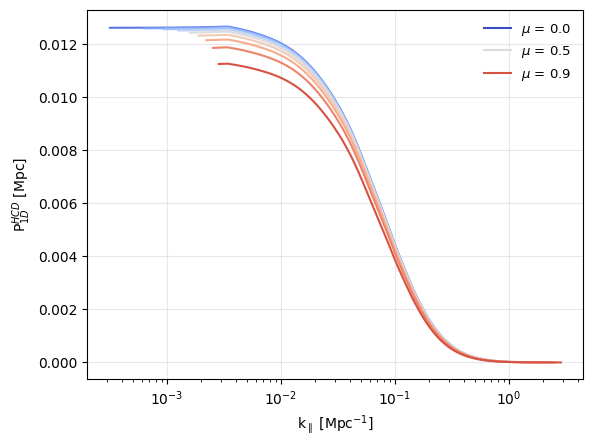

In [99]:
colors = plt.cm.coolwarm(np.linspace(0,1,len(mu)))     
plt.gca().set_prop_cycle('color', colors)

for i in np.arange(len(mu)-1):
    if i in [0, 5, 9]:
        plt.plot(k_los[i, :], p1d_model[i, :], label = '$\mu$ = %.1f' %mu[i])
    else:
        plt.plot(k_los[i, :], p1d_model[i, :])
plt.xscale('log')
plt.grid(alpha=0.3)
plt.legend(fontsize=9.5, frameon=False)
plt.xlabel(r'k$_\parallel$ [Mpc$^{-1}$]')
plt.ylabel(r'P$_{1D}^{HCD}$ [Mpc]');